Berhasil memuat: foto helm.jpeg
Selesai memproses Motion Blur dalam 0.91 detik.
Selesai memproses Blur + Gauss dalam 0.78 detik.
Selesai memproses Blur + S&P dalam 0.72 detik.


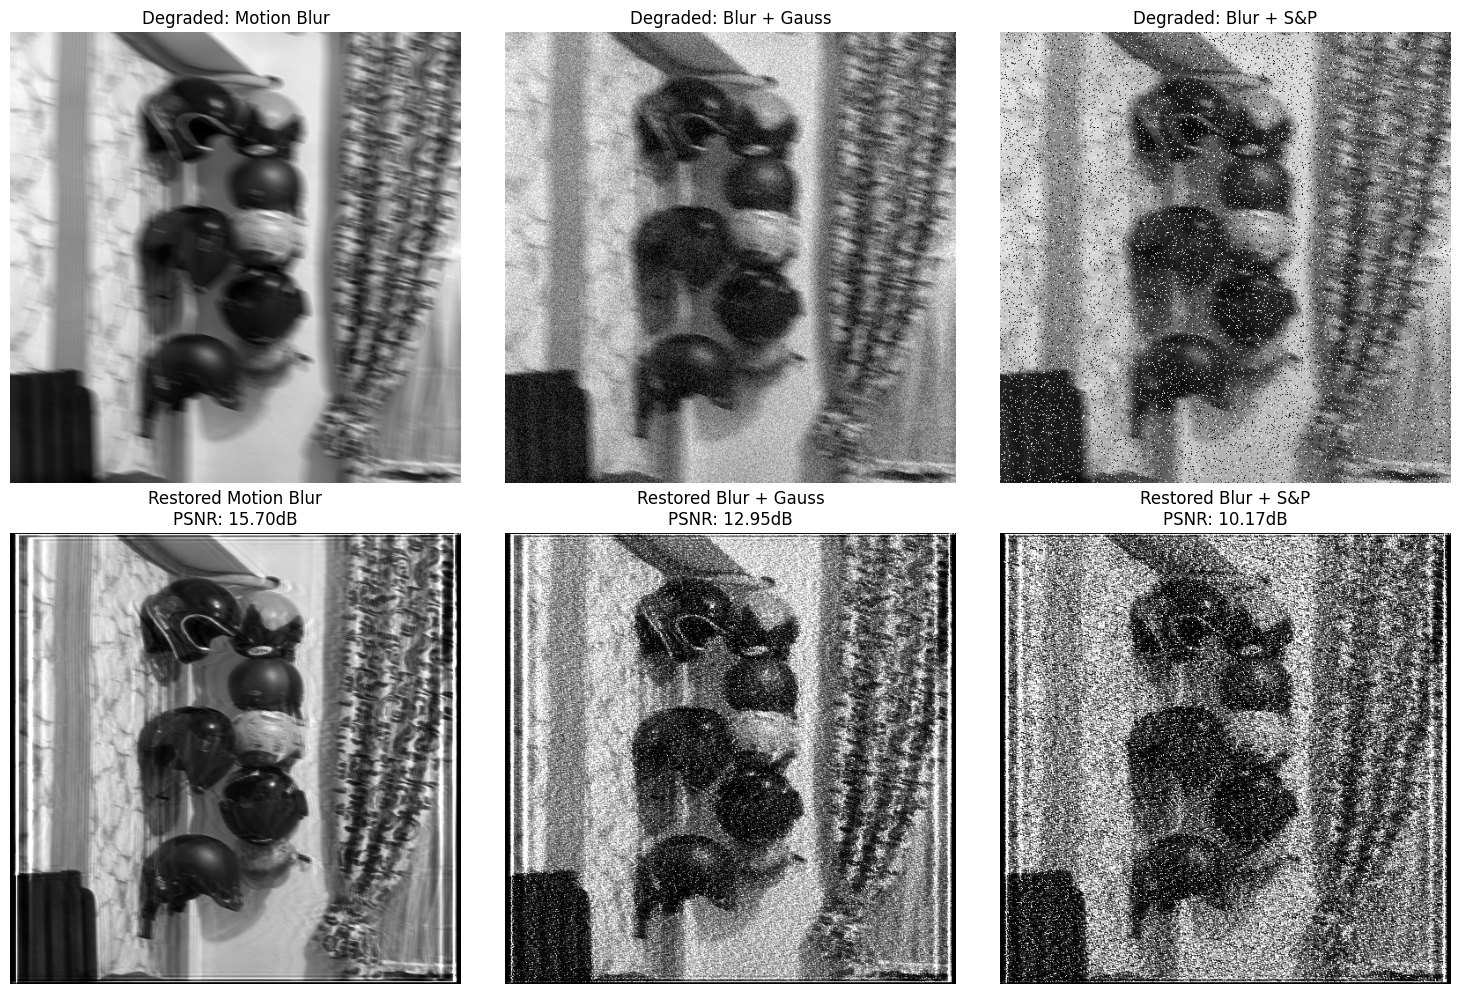

In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import time
from scipy.signal import convolve2d
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage import restoration

# --- Bagian Upload File ---
try:
    from google.colab import files
    print("Silakan upload foto helm Anda:")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]
except ImportError:
    # Jika berjalan secara lokal (bukan Colab)
    file_path = input("Masukkan path/nama file gambar (contoh: foto helm.jpeg): ")

# --- Fungsi Helper ---
def create_motion_blur_kernel(size, angle):
    M = cv2.getRotationMatrix2D((size/2, size/2), angle, 1)
    kernel = np.diag(np.ones(size))
    kernel = cv2.warpAffine(kernel, M, (size, size))
    return kernel / kernel.sum()

def add_noise(image, mode, param):
    if mode == "gaussian":
        noise = np.random.normal(0, param, image.shape)
        return np.clip(image + noise, 0, 255).astype(np.uint8)
    elif mode == "s&p":
        out = image.copy()
        prob = param
        thres = 1 - prob
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                rdn = np.random.random()
                if rdn < prob: out[i][j] = 0
                elif rdn > thres: out[i][j] = 255
        return out

# 1. Load Original Image dengan Proteksi Error
if not os.path.exists(file_path):
    print(f"Error: File {file_path} tidak ditemukan!")
else:
    img = cv2.imread(file_path, 0)
    if img is None:
        print("Error: Gagal membaca file. Pastikan formatnya gambar (jpg/png).")
    else:
        img = cv2.resize(img, (512, 512))
        print(f"Berhasil memuat: {file_path}")

        # 2. Degradation
        psf = create_motion_blur_kernel(15, 30)
        blurred = cv2.filter2D(img, -1, psf)

        deg1 = blurred.copy() # Motion blur only
        deg2 = add_noise(blurred, "gaussian", 20) # Gaussian + Blur
        deg3 = add_noise(blurred, "s&p", 0.05) # S&P + Blur

        scenarios = [("Motion Blur", deg1), ("Blur + Gauss", deg2), ("Blur + S&P", deg3)]
        
        # 3 & 4. Restoration & Visualization
        plt.figure(figsize=(15, 10))
        
        for i, (name, deg_img) in enumerate(scenarios):
            start_time = time.time()
            
            # Wiener Filter (scikit-image) - Menggunakan balance sebagai estimasi 1/SNR
            restored_wiener = restoration.wiener(deg_img.astype(float)/255, psf, balance=0.01)
            
            # Lucy-Richardson (Iterative)
            restored_lr = restoration.richardson_lucy(deg_img.astype(float)/255, psf, num_iter=30)
            
            elapsed = time.time() - start_time
            
            # Metrics (diambil dari hasil Lucy-Richardson sebagai contoh)
            res_uint8 = (restored_lr * 255).astype(np.uint8)
            cur_psnr = psnr(img, res_uint8)
            cur_ssim = ssim(img, res_uint8)

            # Tampilkan Hasil
            plt.subplot(2, 3, i+1)
            plt.imshow(deg_img, cmap='gray')
            plt.title(f"Degraded: {name}")
            plt.axis('off')

            plt.subplot(2, 3, i+4)
            plt.imshow(restored_lr, cmap='gray')
            plt.title(f"Restored {name}\nPSNR: {cur_psnr:.2f}dB")
            plt.axis('off')
            
            print(f"Selesai memproses {name} dalam {elapsed:.2f} detik.")

        plt.tight_layout()
        plt.show()